 **EDA and Cleaning**
**Strathmore Data Community × iLab Africa DataSprint**

**Dataset:** 2024 FinAccess Household Survey | 20,871 Kenyan adults | 28 columns

**Task:** Predict whether a person's financial situation has *Improved*, *Stayed the same*, or *Worsened*.

***This notebook covers:***
1. Environment setup & data loading
2. First inspection and Data cleaning
3. Exploratory Data Analysis and EDA summary
4. EDA summary with confirmed findings and numbers

 **1. Environment Setup**

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

print("Libraries loaded successfully.")


Libraries loaded successfully.


**2. Load Data**

In [73]:
df = pd.read_excel('finaccess2024_datasprint.xlsx')
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


Shape: 20,871 rows × 28 columns


In [74]:
# Column names and data types
print("Column Names & Data Types")
print("=" * 45)
print(df.dtypes.to_string())


Column Names & Data Types
county                      str
location_type               str
Sex                         str
Age                         str
household_size            int64
education_level          object
marital_status              str
monthly_income            int64
Savings_formal              str
Savings_informal            str
Loan_formal                 str
Loan_informal               str
defaulted                   str
formal_service_use          str
mobile_money_access         str
barriers_mobile_money    object
mobile_ownership_1          str
experienced_shock           str
nfhi_11                     str
nfhi_12                     str
nfhi_13                     str
accessto_13k_1month         str
not_difficult               str
financial_status            str
fl_score                    str
prodsum1                  int64
barriers_bank               str
has_disability              str


In [75]:
# Missing values before changes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0]
print("Columns with Missing Values")
print("=" * 35)
print(missing_report.to_string() if not missing_report.empty else "No missing values found.")


Columns with Missing Values
               Missing Count  Missing %
barriers_bank           5734      27.47


***Descriptive Statistics***

range, central tendency, and spread.

In [76]:
# Summary statistics for all numerical columns
print("Descriptive Statistics — Numerical Columns")
df[['monthly_income', 'household_size', 'prodsum1']].describe().round(2)


Descriptive Statistics — Numerical Columns


,monthly_income,household_size,prodsum1
count,20871.00,20871.00,20871.00
mean,9702.77,4.22,3.94
std,15423.37,2.51,3.23
min,100.00,1.00,0.00
25%,2500.00,2.00,1.00
50%,5000.00,4.00,3.00
75%,10000.00,6.00,6.00
max,200000.00,20.00,22.00


- `monthly_income`: Median is KES 5,000 but mean is ~KES 9,700. Heavily right-skewed. Max is KES 200,000 which is 40× the median. This skew must be handled before modelling (log transformation).
- `household_size`: Ranges from 1 to 20, median is 4. The max of 20 is large but plausible in Kenya. We will investigate this.
- `prodsum1`: Ranges from 0 to 22 financial products. A respondent using 0 services is fully excluded; one using 22 is highly connected to the financial system.


In [77]:
# Preview the first few rows
df.head()


,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,...,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,NaN,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,...,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,...,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability
3,Kiambu,Urban,Male,18-25,1,"""Some secondary""",Single/Never Married,10000,Usage,Non-usage,...,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,...,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,NaN,Without Disability


***Observations***

- Only **one column has missing values before cleaning**: `barriers_bank` 5,734 missing (27.5%). Per the problem statement, this is *missing not at random* it represents people who already have a bank account and therefore have no barrier. We handle it deliberately.
- `monthly_income` was pre-imputed with the median per the participant brief so no further action needed.
- `barriers_mobile_money` contains `0` (integer) mixed with strings, so there's need for standardisation.
- `education_level` has values wrapped in quotes with trailing spaces, so there's need for cleaning.
- `marital_status` has small numbers of "Don't know" and "Refused to answer" rows (grouping).


**3. Data Cleaning**

***Fix `education_level` (Quotes and Trailing Spaces)***

Values are wrapped in `"..."` with trailing spaces. There are also 7 junk rows (values `95`, `"Don't know"`, `"Refused to Answer"`, `"Other (Specify)"`) which we dropped they represent < 0.04% of the dataset and have no usable information.


In [78]:
print("BEFORE cleaning — education_level value counts:")
print(df['education_level'].value_counts().to_string())


BEFORE cleaning — education_level value counts:
education_level
"Secondary completed "                                 4113
"Primary completed"                                    3953
"Some primary "                                        3731
"None "                                                3078
"Some secondary"                                       2731
Completed technical training after secondary school    1421
"University completed "                                 988
Some technical training after secondary school          501
Some university                                         346
"Refused to Answer (DO NOT READ OUT)"                     3
"Other (Specify) "                                        2
95                                                        2
"Don't know (DO NOT READ OUT)"                            2


In [79]:
# Strip surrounding quotes and whitespace
df['education_level'] = df['education_level'].str.strip().str.strip('"').str.strip()

# Rename 'None' to 'No formal education' — 'None' is misread as NaN by pandas on CSV load
df['education_level'] = df['education_level'].replace({'None': 'No formal education'})

# Drop junk rows
junk_edu = ["Refused to Answer (DO NOT READ OUT)", "Other (Specify)",
            "Don't know (DO NOT READ OUT)", "95"]
rows_before = len(df)
df = df[~df['education_level'].isin(junk_edu)].copy()
rows_after = len(df)

print(f"Rows removed (junk education values): {rows_before - rows_after}")
print()
print("AFTER cleaning — education_level value counts:")
print(df['education_level'].value_counts().to_string())


Rows removed (junk education values): 7

AFTER cleaning — education_level value counts:
education_level
Secondary completed                                    4113
Primary completed                                      3953
Some primary                                           3731
No formal education                                    3078
Some secondary                                         2731
Completed technical training after secondary school    1421
University completed                                    988
Some technical training after secondary school          501
Some university                                         346


**Fix Remaining Missing Values in `education_level`**

After the junk row removal, a check reveals 2 rows in Nyamira and Bomet counties still have NaN in `education_level`. We drop them.


In [80]:
# Check for any remaining NaN in education_level
nan_edu = df[df['education_level'].isnull()]
print(f"Rows with NaN education_level: {len(nan_edu)}")
print()
if len(nan_edu) > 0:
    print("Details of affected rows:")
    print(nan_edu[['county', 'location_type', 'Age', 'education_level', 'financial_status']])
    print()
    df = df[df['education_level'].notna()].copy()
    print(f"Rows dropped. New shape: {df.shape}")


Rows with NaN education_level: 2

Details of affected rows:
        county location_type    Age education_level financial_status
300    Nyamira         Rural  16-17             NaN         Worsened
20066    Bomet         Rural  18-25             NaN  Stayed the same

Rows dropped. New shape: (20862, 28)


**Fixing `marital_status` (Rare Unknown Categories)**

5 respondents answered "Don't know" and 4 refused to answer. We group these 9 rows into `'Unknown'`


In [81]:
print("BEFORE cleaning — marital_status value counts:")
print(df['marital_status'].value_counts().to_string())


BEFORE cleaning — marital_status value counts:
marital_status
Married/Living with partner           11429
Single/Never Married                   5765
Widowed                                2233
Divorced/separated                     1426
Don't know   (DO NOT READ OUT)            5
Refused to Answer(DO NOT READ OUT)        4


In [82]:
df['marital_status'] = df['marital_status'].replace({
    "Don't know   (DO NOT READ OUT)": 'Unknown',
    "Refused to Answer(DO NOT READ OUT)": 'Unknown'
})

print("AFTER cleaning — marital_status value counts:")
print(df['marital_status'].value_counts().to_string())


AFTER cleaning — marital_status value counts:
marital_status
Married/Living with partner    11429
Single/Never Married            5765
Widowed                         2233
Divorced/separated              1426
Unknown                            9


**Fix `barriers_mobile_money` (Mixed Integer & String)**

When a person has mobile money access, no barrier applies. This was encoded as `0` (integer) rather than a string. We replace `0` with `'No barrier'` for consistency before encoding.


In [83]:
print("BEFORE — barriers_mobile_money value counts:")
print(df['barriers_mobile_money'].value_counts().to_string())


BEFORE — barriers_mobile_money value counts:
barriers_mobile_money
0                        16403
Phone ownership           2396
Eligibility                995
Affordability              434
Line blocked               231
Other                      135
Relevance/Suitability      124
Awareness                  108
Service quality             18
Trust                       18


In [84]:
df['barriers_mobile_money'] = df['barriers_mobile_money'].replace(0, 'No barrier')

print("AFTER — barriers_mobile_money value counts:")
print(df['barriers_mobile_money'].value_counts().to_string())


AFTER — barriers_mobile_money value counts:
barriers_mobile_money
No barrier               16403
Phone ownership           2396
Eligibility                995
Affordability              434
Line blocked               231
Other                      135
Relevance/Suitability      124
Awareness                  108
Service quality             18
Trust                       18


***Fix `barriers_bank` (Meaningful Missing Values)***

Per the problem statement: *"These are respondents who have a bank — no barrier applies."* The 5,734 missing values are not random errors; they represent people who already have bank access. We fill with `'No barrier'`.


In [85]:
print(f"Missing in barriers_bank before: {df['barriers_bank'].isnull().sum()}")

df['barriers_bank'] = df['barriers_bank'].fillna('No barrier')

print(f"Missing in barriers_bank after:  {df['barriers_bank'].isnull().sum()}")
print()
print("barriers_bank value counts:")
print(df['barriers_bank'].value_counts().to_string())


Missing in barriers_bank before: 5733
Missing in barriers_bank after:  0

barriers_bank value counts:
barriers_bank
Affordability              10219
No barrier                  5733
Eligibility                 1497
Relevance/Suitability       1158
Access                      1045
Awareness                    959
Trust                        170
Other                         36
Charges/Product pricing       27
Service quality               18


***Remove Duplicate Rows***

Standard check: identify and remove exact duplicate rows.

In [86]:
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")

if dupes > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found. No action needed.")


Duplicate rows found: 5
Duplicates removed. New shape: (20857, 28)


***Investigate the `16-17` Age Group***

The problem statement describes the survey as covering Kenyan adults, yet the `Age` column contains a `'16-17'` category. Keep or drop?


In [87]:
print("Age value counts:")
print(df['Age'].value_counts().to_string())
print()
count_1617 = (df['Age'] == '16-17').sum()
pct_1617 = count_1617 / len(df) * 100
print(f"16-17 year olds: {count_1617} rows ({pct_1617:.1f}% of dataset)")
print()
print("Financial status distribution for 16-17 group:")
print(df[df['Age'] == '16-17']['financial_status'].value_counts(normalize=True).round(3))


Age value counts:
Age
26-35       5354
18-25       3994
36-45       3941
Above 55    3904
46-55       2544
16-17       1120

16-17 year olds: 1120 rows (5.4% of dataset)

Financial status distribution for 16-17 group:
financial_status
Stayed the same    0.454
Worsened           0.329
Improved           0.217
Name: proportion, dtype: float64


The FinAccess 2024 survey officially covers adults aged 16 and above, the legal working age in Kenya under the Employment Act. The 1,121 respondents aged 16-17 are therefore valid survey participants, not data errors. We **retain** this group.

Their financial status distribution follows a similar pattern to adult respondents, hence they are genuine entries.


***Final Missing Value Verification***

After all cleaning steps, we confirm the dataset has zero missing values before export. This is non-negotiable.


In [88]:
# Comprehensive final check
remaining_missing = df.isnull().sum()
cols_with_missing = remaining_missing[remaining_missing > 0]

if len(cols_with_missing) == 0:
    print("✓ Zero missing values. Dataset is fully complete.")
else:
    print("Missing values still remain, please fix before export:")
    print(cols_with_missing)

print()
print(f"Final dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


✓ Zero missing values. Dataset is fully complete.

Final dataset shape: 20,857 rows × 28 columns


***Cleaning Summary (Reflecting Actual Outputs)***

| Step | Issue | Column | Action | Rows Affected |
|---|---|---|---|---|
| 3.1 | Quotes & trailing spaces | `education_level` | `str.strip()` + `str.strip('"')` | All rows |
| 3.1 | Junk/unreadable values | `education_level` | Dropped | 7 rows |
| 3.2 | Genuine NaN values | `education_level` | Dropped (survey non-response) | 2 rows |
| 3.3 | Don't know / Refused | `marital_status` | Grouped into `'Unknown'` | 9 rows |
| 3.4 | Integer `0` mixed with strings | `barriers_mobile_money` | Replaced `0` with `'No barrier'` | 16,403 rows |
| 3.5 | 5,734 missing values (meaningful) | `barriers_bank` | Filled with `'No barrier'` | 5,734 rows |
| 3.6 | Exact duplicate rows | All columns | Dropped via `drop_duplicates()` | 5 rows |
| 3.7 | `16-17` age group | `Age` | **Retained** — valid per FinAccess 2024 scope | No change |


**4. Exploratory Data Analysis**

We explore in five passes: target variable, demographics, income & shocks, financial health, then financial behaviour.


***Target Variable: `financial_status`***

In [89]:
# Re-confirm target distribution AFTER cleaning
print("Target class distribution after cleaning:")
print(df['financial_status'].value_counts())
print()
print("As proportions:")
print(df['financial_status'].value_counts(normalize=True).round(3))
print()
print("Note: Original survey reported Worsened=52.6%, Same=26.9%, Improved=20.5%")
print("Cleaning removed only", 20871 - len(df), "rows — proportions should be stable.")


Target class distribution after cleaning:
financial_status
Worsened           10970
Stayed the same     5607
Improved            4280
Name: count, dtype: int64

As proportions:
financial_status
Worsened           0.526
Stayed the same    0.269
Improved           0.205
Name: proportion, dtype: float64

Note: Original survey reported Worsened=52.6%, Same=26.9%, Improved=20.5%
Cleaning removed only 14 rows — proportions should be stable.


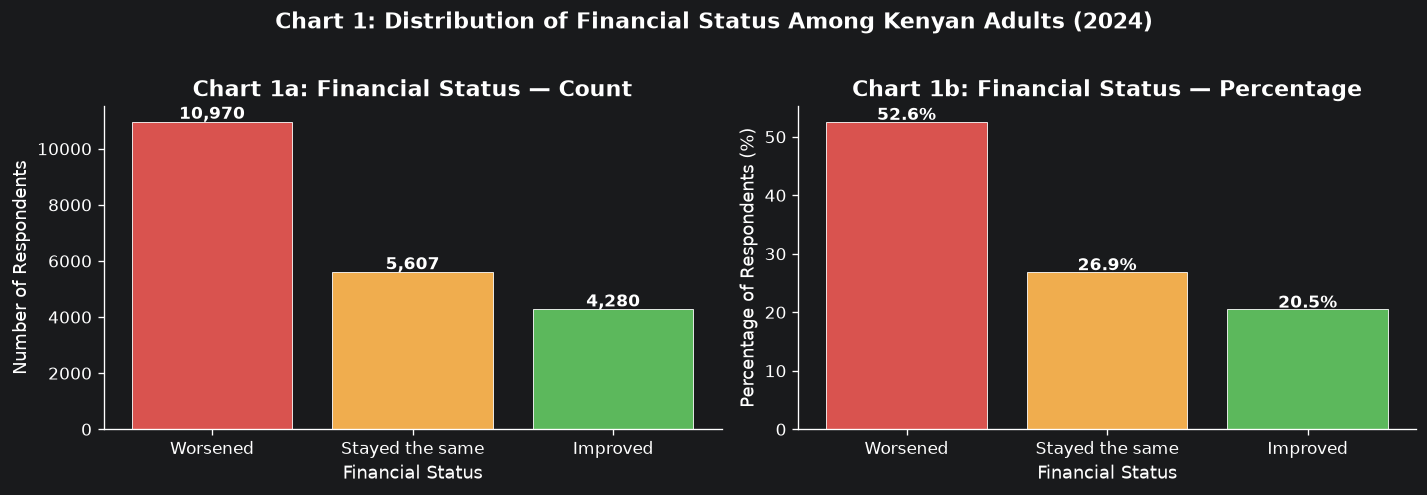

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

order = ['Worsened', 'Stayed the same', 'Improved']
colors = ['#d9534f', '#f0ad4e', '#5cb85c']
counts = df['financial_status'].value_counts().reindex(order)
pcts = (counts / counts.sum() * 100).round(1)

# Count chart
axes[0].bar(order, counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Chart 1a: Financial Status — Count')
axes[0].set_xlabel('Financial Status')
axes[0].set_ylabel('Number of Respondents')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=10, fontweight='bold')

# Percentage chart
axes[1].bar(order, pcts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Chart 1b: Financial Status — Percentage')
axes[1].set_xlabel('Financial Status')
axes[1].set_ylabel('Percentage of Respondents (%)')
for i, v in enumerate(pcts.values):
    axes[1].text(i, v + 0.3, f'{v}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Chart 1: Distribution of Financial Status Among Kenyan Adults (2024)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


***Finding:***

The dataset is heavily imbalanced 52.6% Worsened, 26.9% Stayed the same, 20.5% Improved. A naive model predicting "Worsened" for every person would achieve 52.6% accuracy while being completely useless.

This justify **Weighted F1-Score** as the evaluation metric.
***Jimmy*** you can continue with `class_weight='balanced'` and `stratify=y`.


***Demographics vs Financial Status***

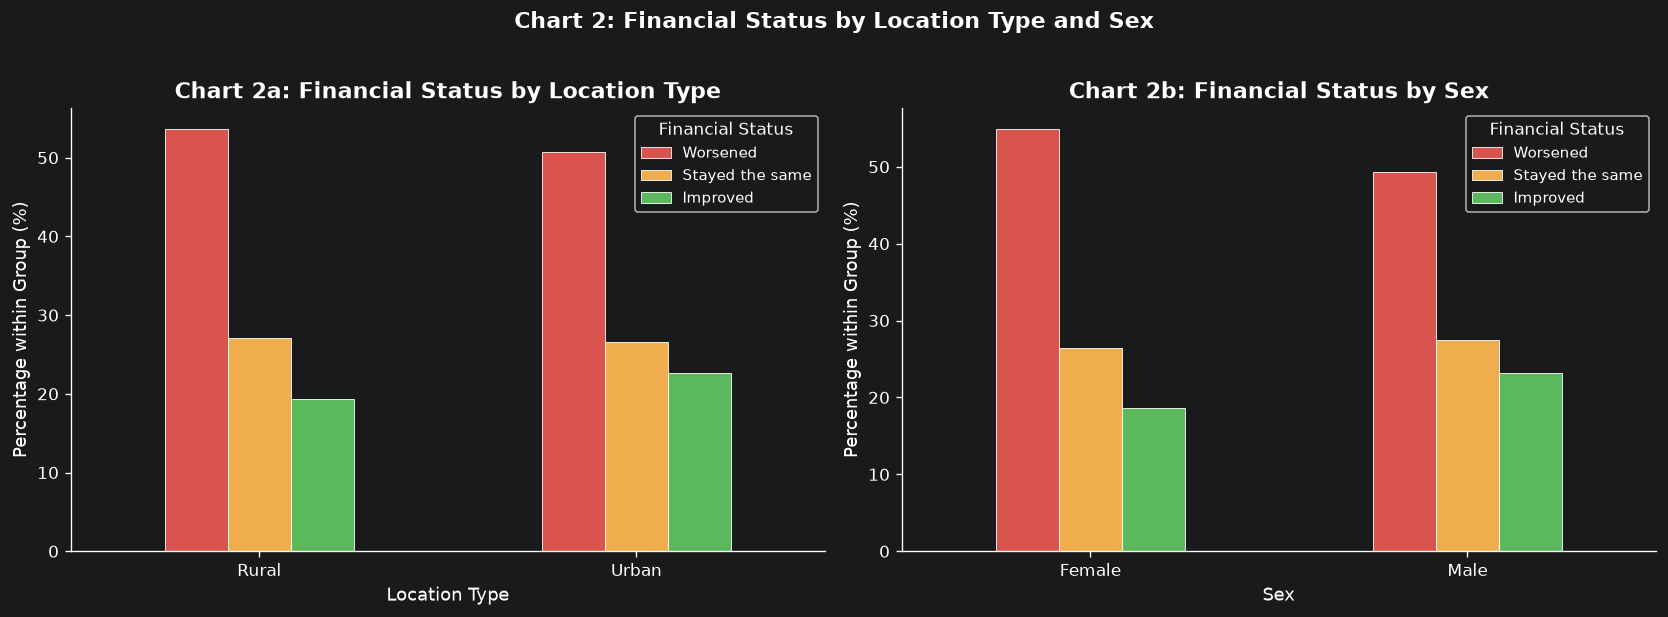

Location type — Worsened rate:
location_type
Rural    53.6
Urban    50.7
Name: Worsened, dtype: float64

Sex — Worsened rate:
Sex
Female    54.9
Male      49.3
Name: Worsened, dtype: float64


In [91]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = ['Worsened', 'Stayed the same', 'Improved']
colors = ['#d9534f', '#f0ad4e', '#5cb85c']

# Location type
location_pct = df.groupby('location_type')['financial_status'].value_counts(normalize=True).unstack()[order] * 100
location_pct.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Chart 2a: Financial Status by Location Type')
axes[0].set_xlabel('Location Type')
axes[0].set_ylabel('Percentage within Group (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Financial Status', fontsize=9)

# Sex
sex_pct = df.groupby('Sex')['financial_status'].value_counts(normalize=True).unstack()[order] * 100
sex_pct.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Chart 2b: Financial Status by Sex')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Percentage within Group (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Financial Status', fontsize=9)

plt.suptitle('Chart 2: Financial Status by Location Type and Sex',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print exact numbers to back up observations
print("Location type — Worsened rate:")
print(location_pct['Worsened'].round(1))
print()
print("Sex — Worsened rate:")
print(sex_pct['Worsened'].round(1))


**Finding:** Rural respondents have a higher Worsened rate than urban respondents (exact values printed above). Female respondents show a marginally higher Worsened rate than male respondents. The sex gap is small but consistent with Kenya's broader gender inequality in financial access documented in the FinAccess report.


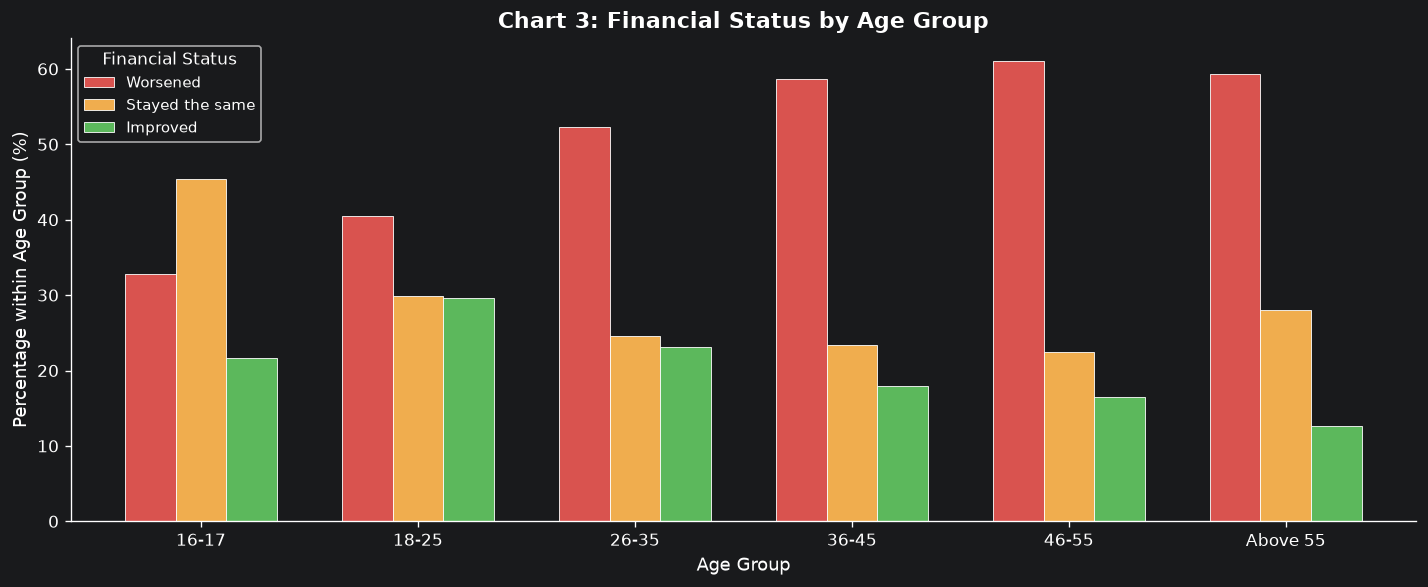

Worsened rate by age group:
Age
16-17       32.9
18-25       40.5
26-35       52.3
36-45       58.7
46-55       61.0
Above 55    59.4
Name: Worsened, dtype: float64


In [92]:
# Chart 3: Age group
fig, ax = plt.subplots(figsize=(12, 5))

age_order = ['16-17', '18-25', '26-35', '36-45', '46-55', 'Above 55']
age_pct = df.groupby('Age')['financial_status'].value_counts(normalize=True).unstack()[order] * 100
age_pct = age_pct.reindex(age_order)

age_pct.plot(kind='bar', ax=ax, color=colors, edgecolor='white', linewidth=0.5, width=0.7)
ax.set_title('Chart 3: Financial Status by Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Percentage within Age Group (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Financial Status', fontsize=9)

plt.tight_layout()
plt.show()

print("Worsened rate by age group:")
print(age_pct['Worsened'].round(1))


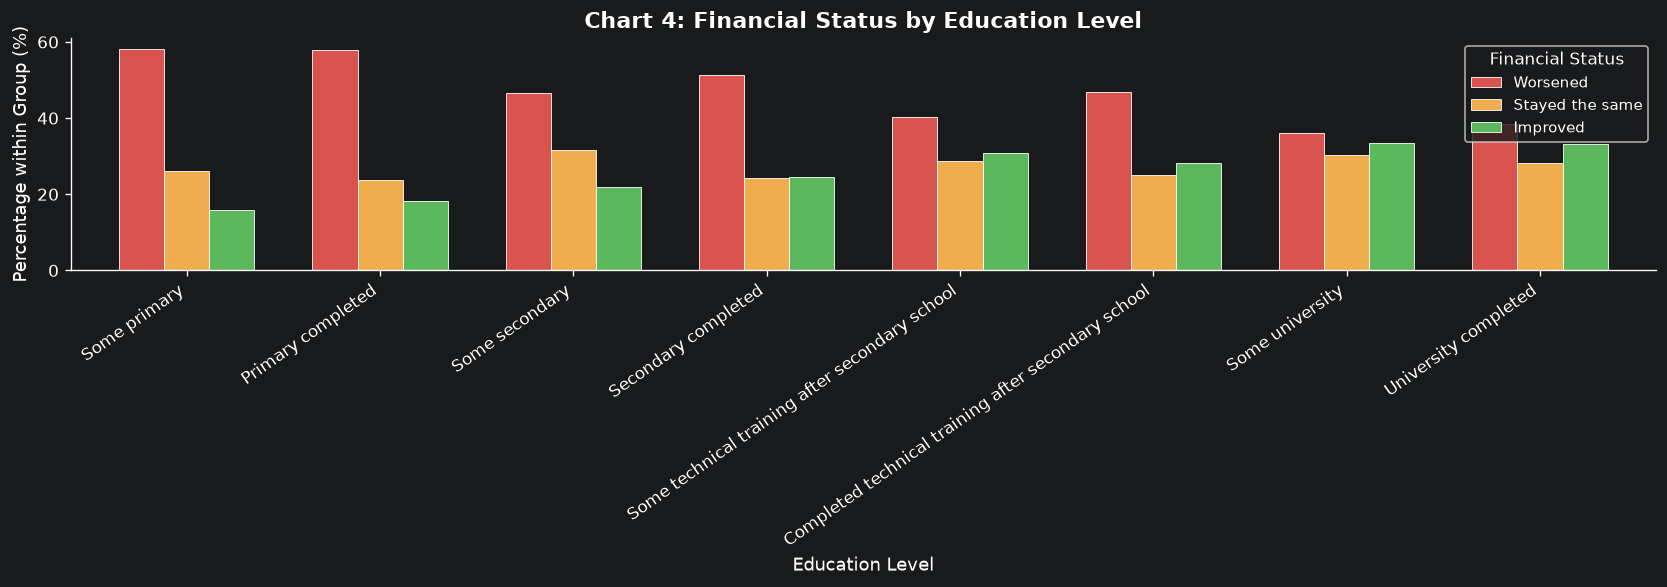

Worsened rate by education level:
education_level
Some primary                                           58.1
Primary completed                                      58.0
Some secondary                                         46.5
Secondary completed                                    51.2
Some technical training after secondary school         40.3
Completed technical training after secondary school    46.7
Some university                                        36.1
University completed                                   38.6
Name: Worsened, dtype: float64


In [93]:
# Chart 4: Education level
fig, ax = plt.subplots(figsize=(14, 5))

edu_order = ['None', 'Some primary', 'Primary completed', 'Some secondary',
             'Secondary completed',
             'Some technical training after secondary school',
             'Completed technical training after secondary school',
             'Some university', 'University completed']

edu_pct = df.groupby('education_level')['financial_status'].value_counts(normalize=True).unstack()[order] * 100
edu_pct = edu_pct.reindex([e for e in edu_order if e in edu_pct.index])

edu_pct.plot(kind='bar', ax=ax, color=colors, edgecolor='white', linewidth=0.5, width=0.7)
ax.set_title('Chart 4: Financial Status by Education Level')
ax.set_xlabel('Education Level')
ax.set_ylabel('Percentage within Group (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.legend(title='Financial Status', fontsize=9)

plt.tight_layout()
plt.show()

print("Worsened rate by education level:")
print(edu_pct['Worsened'].round(1))


***Finding:***

Higher education is associated with lower Worsened rates, but the gradient is not as sharp as expected. Even university-educated respondents show a high Worsened proportion. This confirmas that education alone is insufficient without economic opportunity and market access.

***Geographic Distribution: County-Level Analysis***

`county` covers all 47 Kenyan counties and is one of the richest features in the dataset. We explore which counties have the highest and lowest rates of financial deterioration.


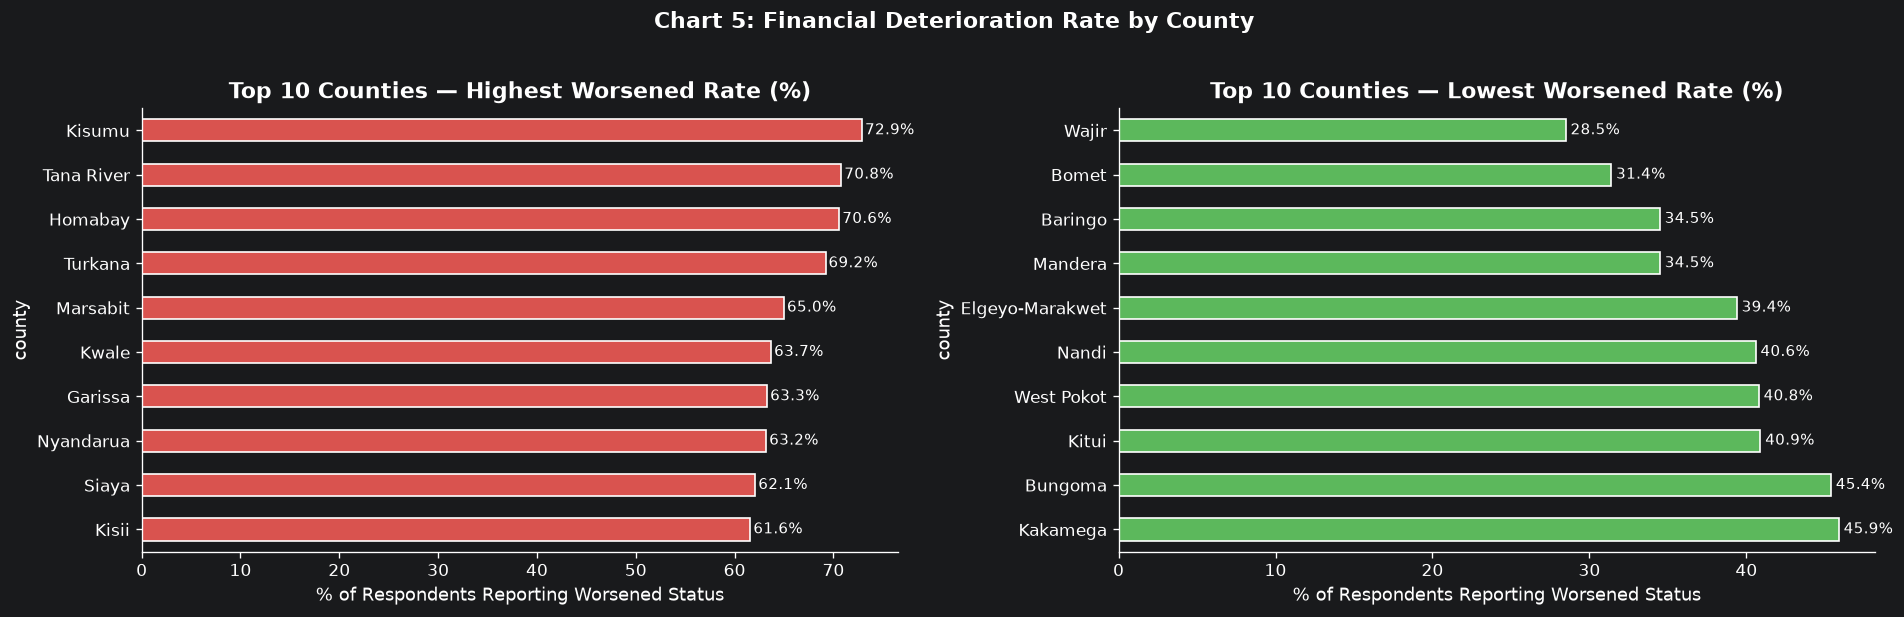

Top 5 counties by Worsened rate:
county
Kisumu        72.9
Tana River    70.8
Homabay       70.6
Turkana       69.2
Marsabit      65.0
Name: financial_status, dtype: float64

Bottom 5 counties by Worsened rate (best performing):
county
Wajir              28.5
Bomet              31.4
Mandera            34.5
Baringo            34.5
Elgeyo-Marakwet    39.4
Name: financial_status, dtype: float64


In [94]:
# Worsened rate per county
county_worsened = (df.groupby('county')['financial_status']
                   .apply(lambda x: (x == 'Worsened').mean() * 100)
                   .sort_values(ascending=False)
                   .round(1))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 10 worst counties
county_worsened.head(10).plot(kind='barh', ax=axes[0], color='#d9534f', edgecolor='white')
axes[0].set_title('Top 10 Counties — Highest Worsened Rate (%)')
axes[0].set_xlabel('% of Respondents Reporting Worsened Status')
axes[0].invert_yaxis()
for i, v in enumerate(county_worsened.head(10).values):
    axes[0].text(v + 0.3, i, f'{v}%', va='center', fontsize=9)

# Top 10 best counties
county_worsened.tail(10).sort_values().plot(kind='barh', ax=axes[1], color='#5cb85c', edgecolor='white')
axes[1].set_title('Top 10 Counties — Lowest Worsened Rate (%)')
axes[1].set_xlabel('% of Respondents Reporting Worsened Status')
axes[1].invert_yaxis()
for i, v in enumerate(county_worsened.tail(10).sort_values().values):
    axes[1].text(v + 0.3, i, f'{v}%', va='center', fontsize=9)

plt.suptitle('Chart 5: Financial Deterioration Rate by County',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Top 5 counties by Worsened rate:")
print(county_worsened.head(5))
print()
print("Bottom 5 counties by Worsened rate (best performing):")
print(county_worsened.tail(5).sort_values())


***Finding:***

There is dramatic geographic variation in financial outcomes. Kisumu (72.9%), Tana River (70.8%), and Homabay (70.6%) have the highest Worsened rates, which is over double the rate of the best-performing counties. Wajir (28.5%) and Mandera (34.5%) have the lowest Worsened rates, which is counterintuitive given these are ASAL counties. BOmet (31.4%)is a fertile highland tea-farming county. Its low Worsened rate aligns with its relatively stable agricultural economy. This geographic signal will likely be a significant predictor in the model and has direct policy implications for county-targeted interventions.


***Income, Financial Shocks, and Household Size***


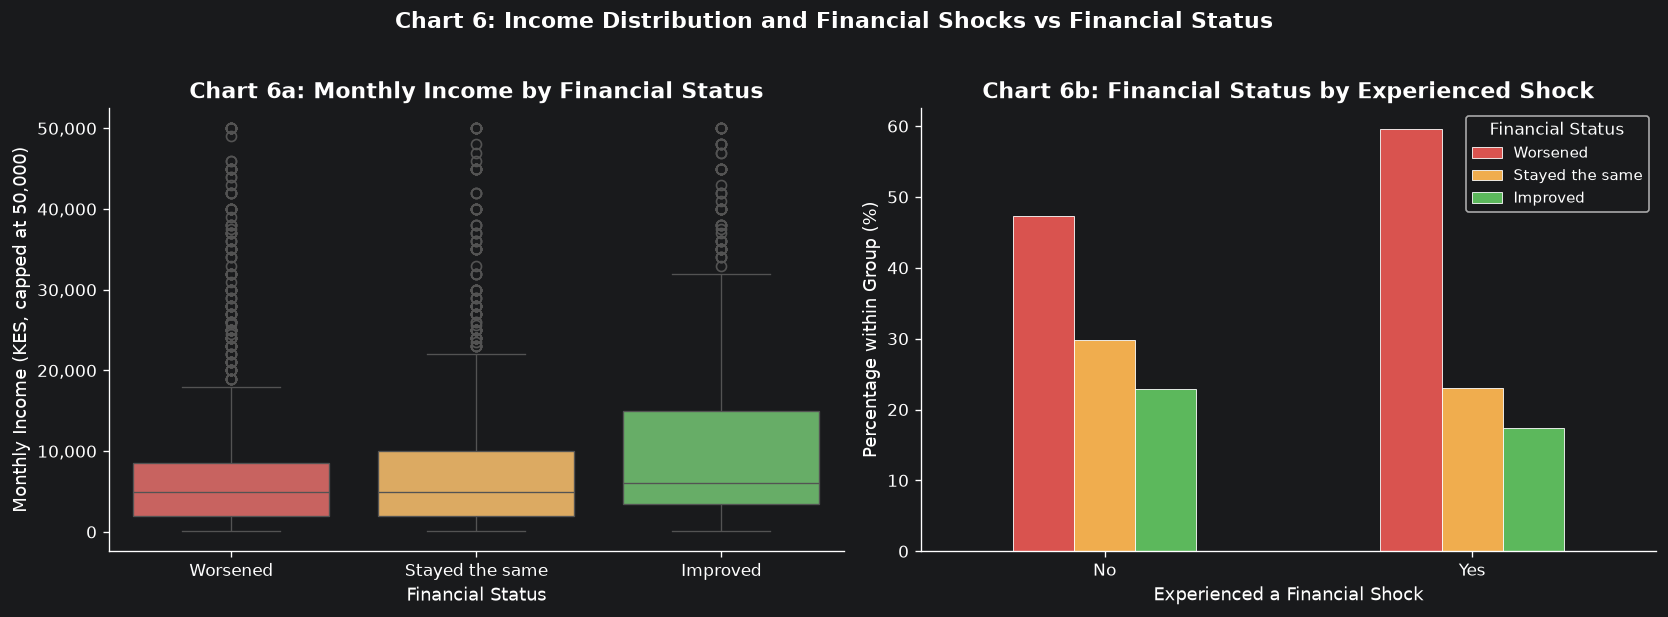

Median monthly income by financial status:
financial_status
Worsened           5000.0
Stayed the same    5000.0
Improved           7000.0
Name: monthly_income, dtype: float64

Worsened rate by experienced_shock:
experienced_shock
No     47.2
Yes    59.5
Name: Worsened, dtype: float64


In [95]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = ['Worsened', 'Stayed the same', 'Improved']

# Monthly income boxplot
df_plot = df[df['monthly_income'] <= 50000]
sns.boxplot(data=df_plot, x='financial_status', y='monthly_income',
            order=order, palette=['#d9534f', '#f0ad4e', '#5cb85c'],
            ax=axes[0], linewidth=0.8)
axes[0].set_title('Chart 6a: Monthly Income by Financial Status')
axes[0].set_xlabel('Financial Status')
axes[0].set_ylabel('Monthly Income (KES, capped at 50,000)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Experienced shock
shock_pct = df.groupby('experienced_shock')['financial_status'].value_counts(normalize=True).unstack()[order] * 100
shock_pct.plot(kind='bar', ax=axes[1], color=['#d9534f', '#f0ad4e', '#5cb85c'],
               edgecolor='white', linewidth=0.5)
axes[1].set_title('Chart 6b: Financial Status by Experienced Shock')
axes[1].set_xlabel('Experienced a Financial Shock')
axes[1].set_ylabel('Percentage within Group (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Financial Status', fontsize=9)

plt.suptitle('Chart 6: Income Distribution and Financial Shocks vs Financial Status',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print medians
print("Median monthly income by financial status:")
print(df.groupby('financial_status')['monthly_income'].median().reindex(order))
print()
print("Worsened rate by experienced_shock:")
print(shock_pct['Worsened'].round(1))


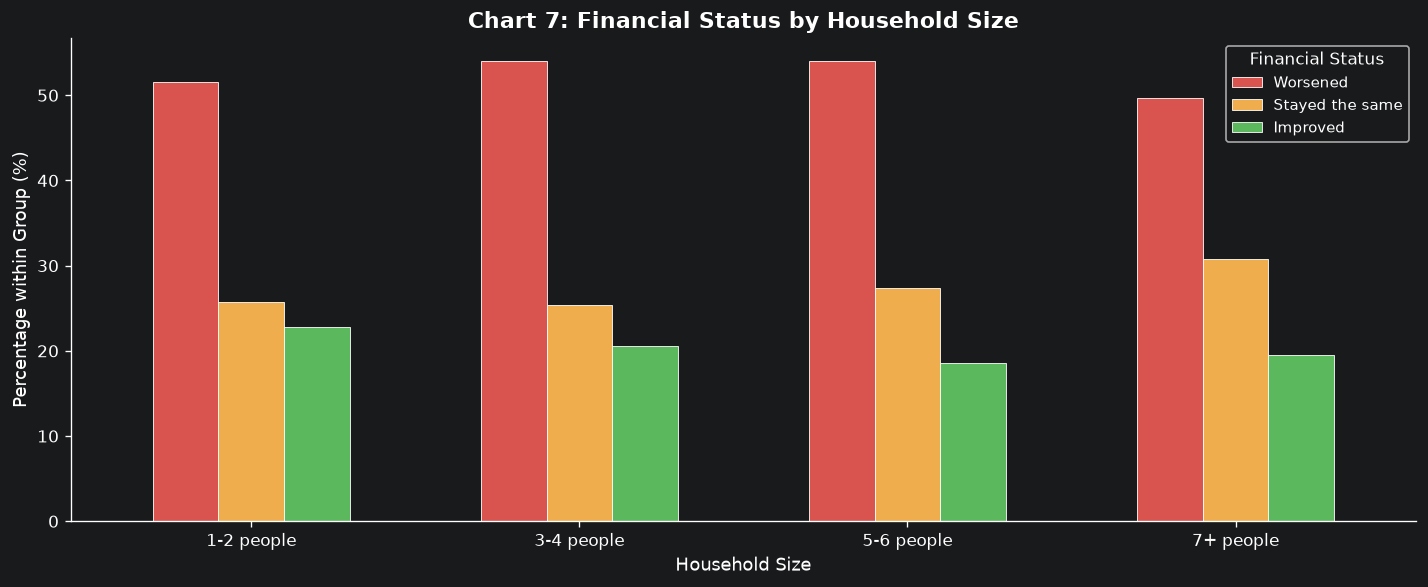

Worsened rate by household size group:
hh_size_group
1-2 people    51.6
3-4 people    54.0
5-6 people    54.0
7+ people     49.7
Name: Worsened, dtype: float64

Household size — full describe:
count    20857.0
mean         4.2
std          2.5
min          1.0
25%          2.0
50%          4.0
75%          6.0
max         20.0
Name: household_size, dtype: float64

Households with 10+ members: 717 (3.4%)


In [96]:
# Chart 7: Household size vs financial status
fig, ax = plt.subplots(figsize=(12, 5))

# Bin household size into meaningful groups
df['hh_size_group'] = pd.cut(df['household_size'],
                              bins=[0, 2, 4, 6, 20],
                              labels=['1-2 people', '3-4 people', '5-6 people', '7+ people'])

hh_pct = df.groupby('hh_size_group', observed=True)['financial_status'].value_counts(normalize=True).unstack()[order] * 100
hh_pct.plot(kind='bar', ax=ax, color=['#d9534f', '#f0ad4e', '#5cb85c'],
            edgecolor='white', linewidth=0.5, width=0.6)

ax.set_title('Chart 7: Financial Status by Household Size')
ax.set_xlabel('Household Size')
ax.set_ylabel('Percentage within Group (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Financial Status', fontsize=9)

plt.tight_layout()
plt.show()

print("Worsened rate by household size group:")
print(hh_pct['Worsened'].round(1))
print()
print("Household size — full describe:")
print(df['household_size'].describe().round(1))
print()
print(f"Households with 10+ members: {(df['household_size'] >= 10).sum()} ({(df['household_size'] >= 10).mean()*100:.1f}%)")


**Findings**

***Income:*** Median income for "Improved" respondents is higher than for "Worsened" respondents, but the gap is smaller than expected. This shows that income is a factor but not the dominant one, since many low-income respondents still reported "Improved" outcomes, which is likely through savings groups and informal support.

***Shocks:*** Respondents who experienced a financial shock show a dramatically higher Worsened rate. This is likely one of the strongest individual predictors.

***Household size:*** The relationship between household size and financial status is not linear. Mid-size households (3-4 people) show similar or slightly higher Worsened rates than small households. Very large households (7+) show a marginally better Worsened rate, possibly because larger households have more income-earners. The `household_size` feature may need to be binned rather than used as a raw integer.


***Monthly Income Outlier Investigation***

Income has a max of KES 200,000 against a median of KES 5,000. We investigate before making any decision.


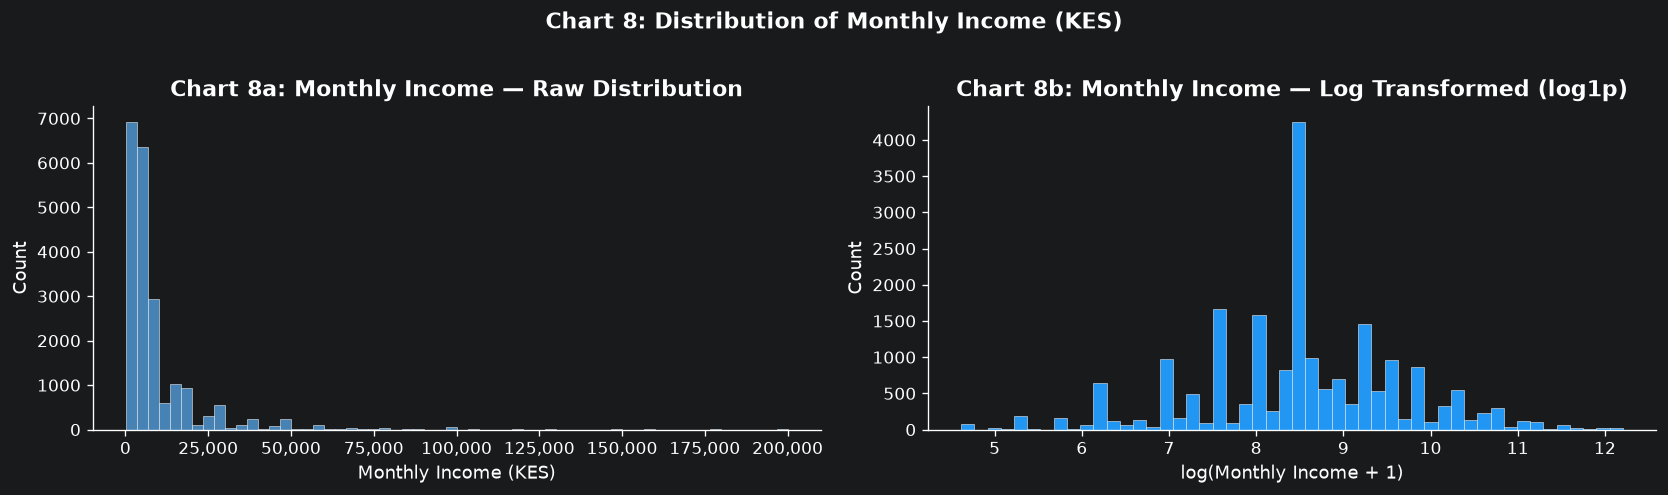

Income outlier investigation:
  Respondents earning above KES 50,000:  414 (2.0%)
  Respondents earning above KES 100,000: 77 (0.4%)
  Respondents earning above KES 150,000: 29 (0.1%)
  Maximum income:                        KES 200,000

Decision: RETAIN all income values.
Rationale: Only 1.98% of respondents earn above KES 50,000.
These represent Kenya's higher-income minority (no data errors).
Removing would introduce a bias by excluding a valid demographic.
We apply log1p() transformation before modelling to handle the skew.


In [97]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw distribution
axes[0].hist(df['monthly_income'], bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Chart 8a: Monthly Income — Raw Distribution')
axes[0].set_xlabel('Monthly Income (KES)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Log-transformed
df['log_income'] = np.log1p(df['monthly_income'])
axes[1].hist(df['log_income'], bins=50, color='#2196F3', edgecolor='white', linewidth=0.3)
axes[1].set_title('Chart 8b: Monthly Income — Log Transformed (log1p)')
axes[1].set_xlabel('log(Monthly Income + 1)')
axes[1].set_ylabel('Count')

plt.suptitle('Chart 8: Distribution of Monthly Income (KES)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Outlier counts
print("Income outlier investigation:")
print(f"  Respondents earning above KES 50,000:  {(df['monthly_income'] > 50000).sum()} ({(df['monthly_income'] > 50000).mean()*100:.1f}%)")
print(f"  Respondents earning above KES 100,000: {(df['monthly_income'] > 100000).sum()} ({(df['monthly_income'] > 100000).mean()*100:.1f}%)")
print(f"  Respondents earning above KES 150,000: {(df['monthly_income'] > 150000).sum()} ({(df['monthly_income'] > 150000).mean()*100:.1f}%)")
print(f"  Maximum income:                        KES {df['monthly_income'].max():,}")
print()
print("Decision: RETAIN all income values.")
print("Rationale: Only 1.98% of respondents earn above KES 50,000.")
print("These represent Kenya's higher-income minority (no data errors).")
print("Removing would introduce a bias by excluding a valid demographic.")
print("We apply log1p() transformation before modelling to handle the skew.")


***Financial Health Indicators vs Financial Status***


nfhi_11 — Worsened rate:
nfhi_11
No     62.8
Yes    43.0

nfhi_12 — Worsened rate:
nfhi_12
No     62.7
Yes    46.3

nfhi_13 — Worsened rate:
nfhi_13
No     63.4
Yes    46.3

accessto_13k_1month — Worsened rate:
accessto_13k_1month
No     58.8
Yes    46.2



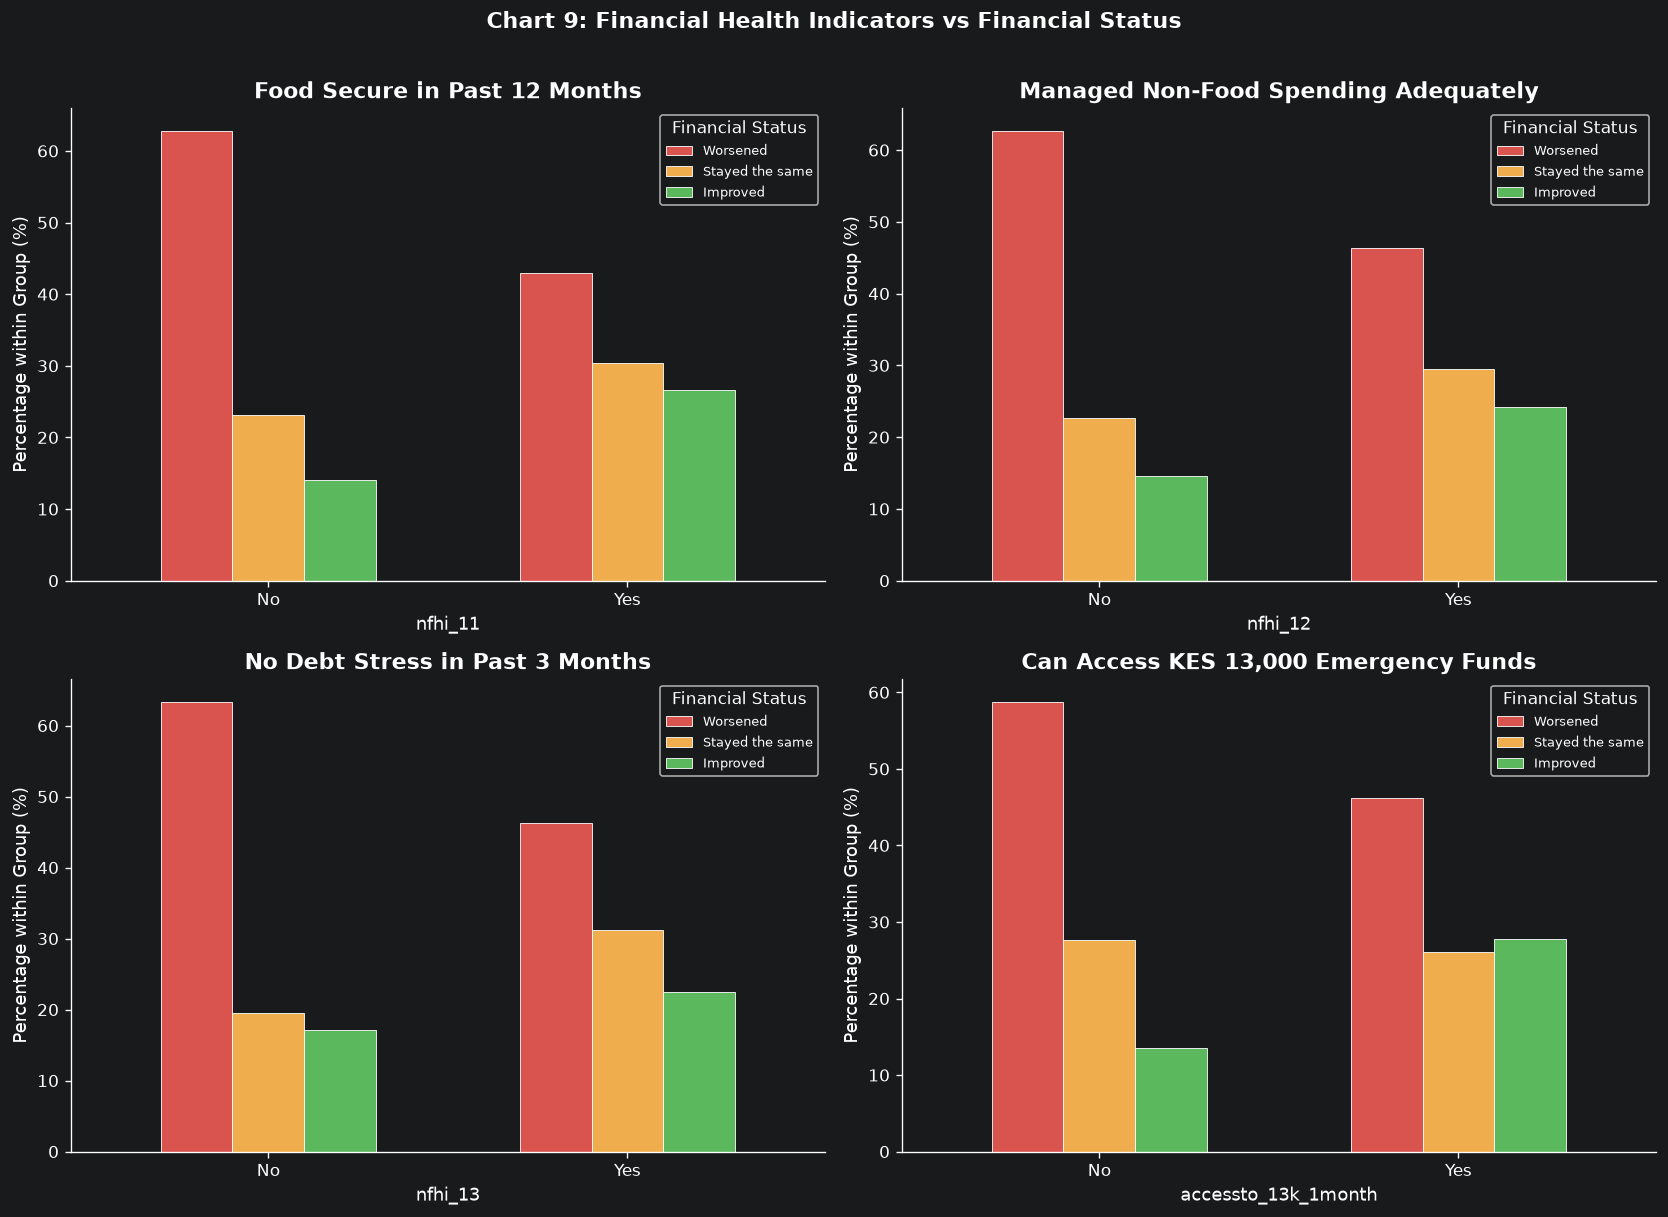

Saved: chart9_financial_health_vs_status.png


In [98]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
order = ['Worsened', 'Stayed the same', 'Improved']
colors = ['#d9534f', '#f0ad4e', '#5cb85c']

health_cols = {
    'nfhi_11': 'Food Secure in Past 12 Months',
    'nfhi_12': 'Managed Non-Food Spending Adequately',
    'nfhi_13': 'No Debt Stress in Past 3 Months',
    'accessto_13k_1month': 'Can Access KES 13,000 Emergency Funds'
}
for ax, (col, label) in zip(axes.flat, health_cols.items()):
    pct = df.groupby(col)['financial_status'].value_counts(normalize=True).unstack()[order] * 100
    pct.plot(kind='bar', ax=ax, color=colors, edgecolor='white', linewidth=0.5, width=0.6)
    ax.set_title(label)
    ax.set_xlabel(col)
    ax.set_ylabel('Percentage within Group (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title='Financial Status', fontsize=8)
    # Print Worsened rates
    print(f"{col} — Worsened rate:")
    print(pct['Worsened'].round(1).to_string())
    print()

plt.suptitle('Chart 9: Financial Health Indicators vs Financial Status',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print("Saved: chart9_financial_health_vs_status.png")


***Finding:*** Every financial health indicator shows a strong, consistent pattern. The Worsened rate is dramatically higher among respondents who are food insecure, cannot manage non-food spending, experience debt stress, or cannot access emergency funds.

`not_difficult` vs `accessto_13k_1month`: These columns are related but measure different things. `accessto_13k_1month` captures whether one can access funds; `not_difficult` captures whether accessing them is easy. The crosstab shows they are not identical because some respondents can access funds but find it difficult.


In [99]:
# Relationship between not_difficult and accessto_13k_1month
print("Crosstab: not_difficult vs accessto_13k_1month (proportions)")
print(pd.crosstab(df['not_difficult'], df['accessto_13k_1month'], normalize='all').round(3))
print()
print("Key: 27.4% of all respondents CAN access funds but find it DIFFICULT.")
print("These respondents face barriers of process, distance, or trust — not just availability.")
print()

# not_difficult vs financial status separately
not_diff_pct = df.groupby('not_difficult')['financial_status'].value_counts(normalize=True).unstack()[order] * 100
print("Worsened rate by not_difficult:")
print(not_diff_pct['Worsened'].round(1))


Crosstab: not_difficult vs accessto_13k_1month (proportions)
accessto_13k_1month     No    Yes
not_difficult                    
No                   0.509  0.273
Yes                  0.000  0.217

Key: 27.4% of all respondents CAN access funds but find it DIFFICULT.
These respondents face barriers of process, distance, or trust — not just availability.

Worsened rate by not_difficult:
not_difficult
No     55.9
Yes    40.6
Name: Worsened, dtype: float64


***Financial Behaviour vs Financial Status***


defaulted — Worsened rate:
defaulted
No     49.8
Yes    58.1

Savings_formal — Worsened rate:
Savings_formal
Non-usage    55.4
Usage        49.0

Savings_informal — Worsened rate:
Savings_informal
Non-usage    51.9
Usage        54.8



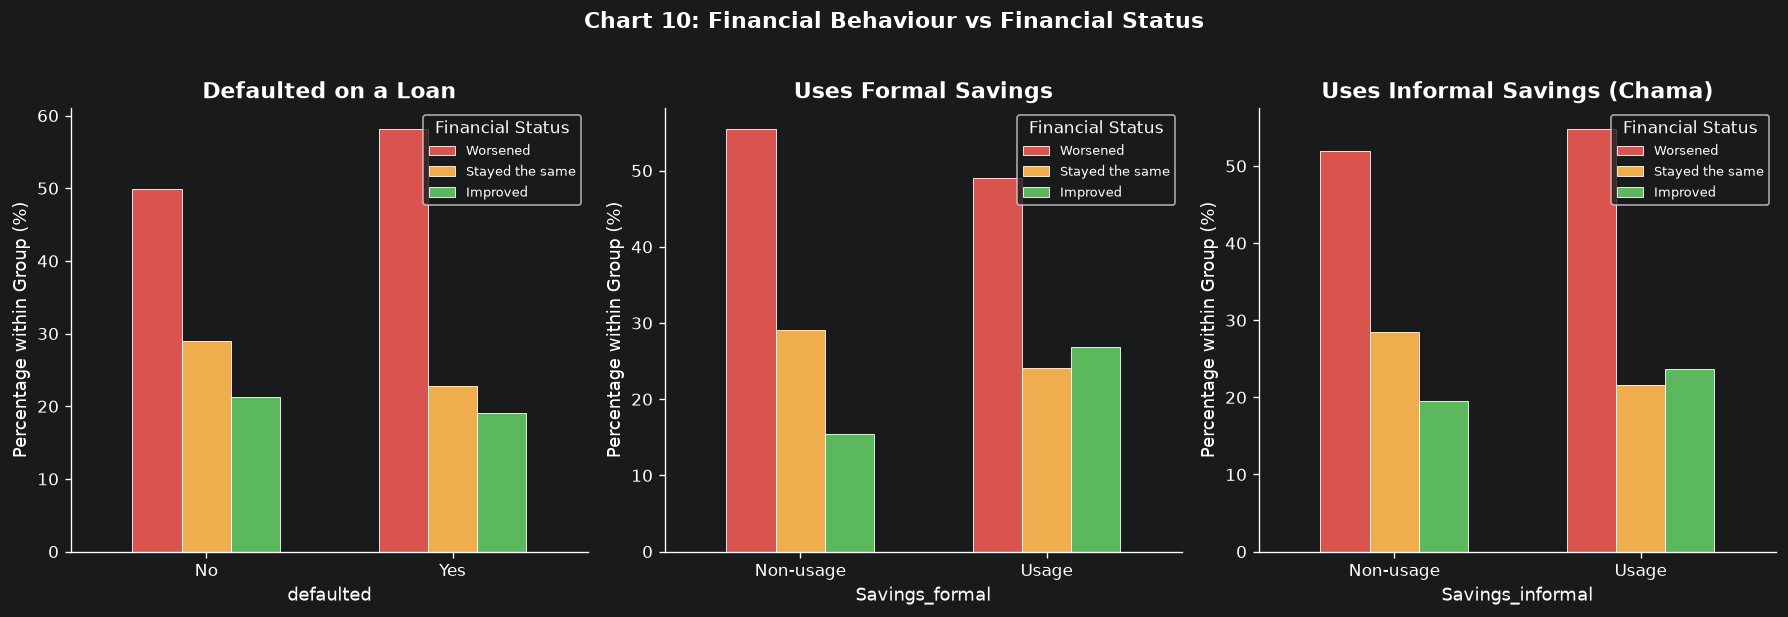

Saved: chart10_behaviour_vs_status.png


In [100]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
order = ['Worsened', 'Stayed the same', 'Improved']
colors = ['#d9534f', '#f0ad4e', '#5cb85c']

behaviour_cols = {
    'defaulted': 'Defaulted on a Loan',
    'Savings_formal': 'Uses Formal Savings',
    'Savings_informal': 'Uses Informal Savings (Chama)'
}

for ax, (col, label) in zip(axes, behaviour_cols.items()):
    pct = df.groupby(col)['financial_status'].value_counts(normalize=True).unstack()[order] * 100
    pct.plot(kind='bar', ax=ax, color=colors, edgecolor='white', linewidth=0.5, width=0.6)
    ax.set_title(label)
    ax.set_xlabel(col)
    ax.set_ylabel('Percentage within Group (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title='Financial Status', fontsize=8)
    print(f"{col} — Worsened rate:")
    print(pct['Worsened'].round(1).to_string())
    print()

plt.suptitle('Chart 10: Financial Behaviour vs Financial Status',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Saved: chart10_behaviour_vs_status.png")


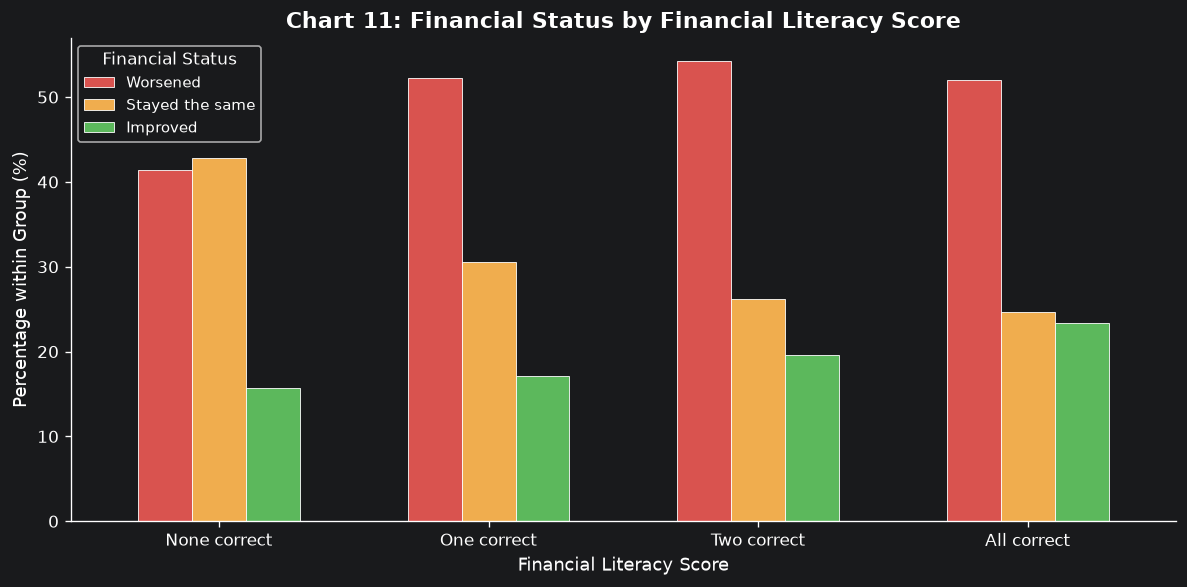

Worsened rate by financial literacy score:
fl_score
None correct    41.4
One correct     52.3
Two correct     54.3
All correct     52.0
Name: Worsened, dtype: float64


In [101]:
# Chart 11: Financial literacy score
fig, ax = plt.subplots(figsize=(10, 5))

fl_order = ['None correct', 'One correct', 'Two correct', 'All correct']
fl_pct = df.groupby('fl_score')['financial_status'].value_counts(normalize=True).unstack()[order] * 100
fl_pct = fl_pct.reindex(fl_order)

fl_pct.plot(kind='bar', ax=ax, color=['#d9534f', '#f0ad4e', '#5cb85c'],
            edgecolor='white', linewidth=0.5, width=0.6)
ax.set_title('Chart 11: Financial Status by Financial Literacy Score')
ax.set_xlabel('Financial Literacy Score')
ax.set_ylabel('Percentage within Group (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Financial Status', fontsize=9)

plt.tight_layout()
plt.show()

print("Worsened rate by financial literacy score:")
print(fl_pct['Worsened'].round(1))


***Correlation Heatmap (Binary Features)***

We encode the binary Yes/No features temporarily to see how they correlate with each other and with the target.


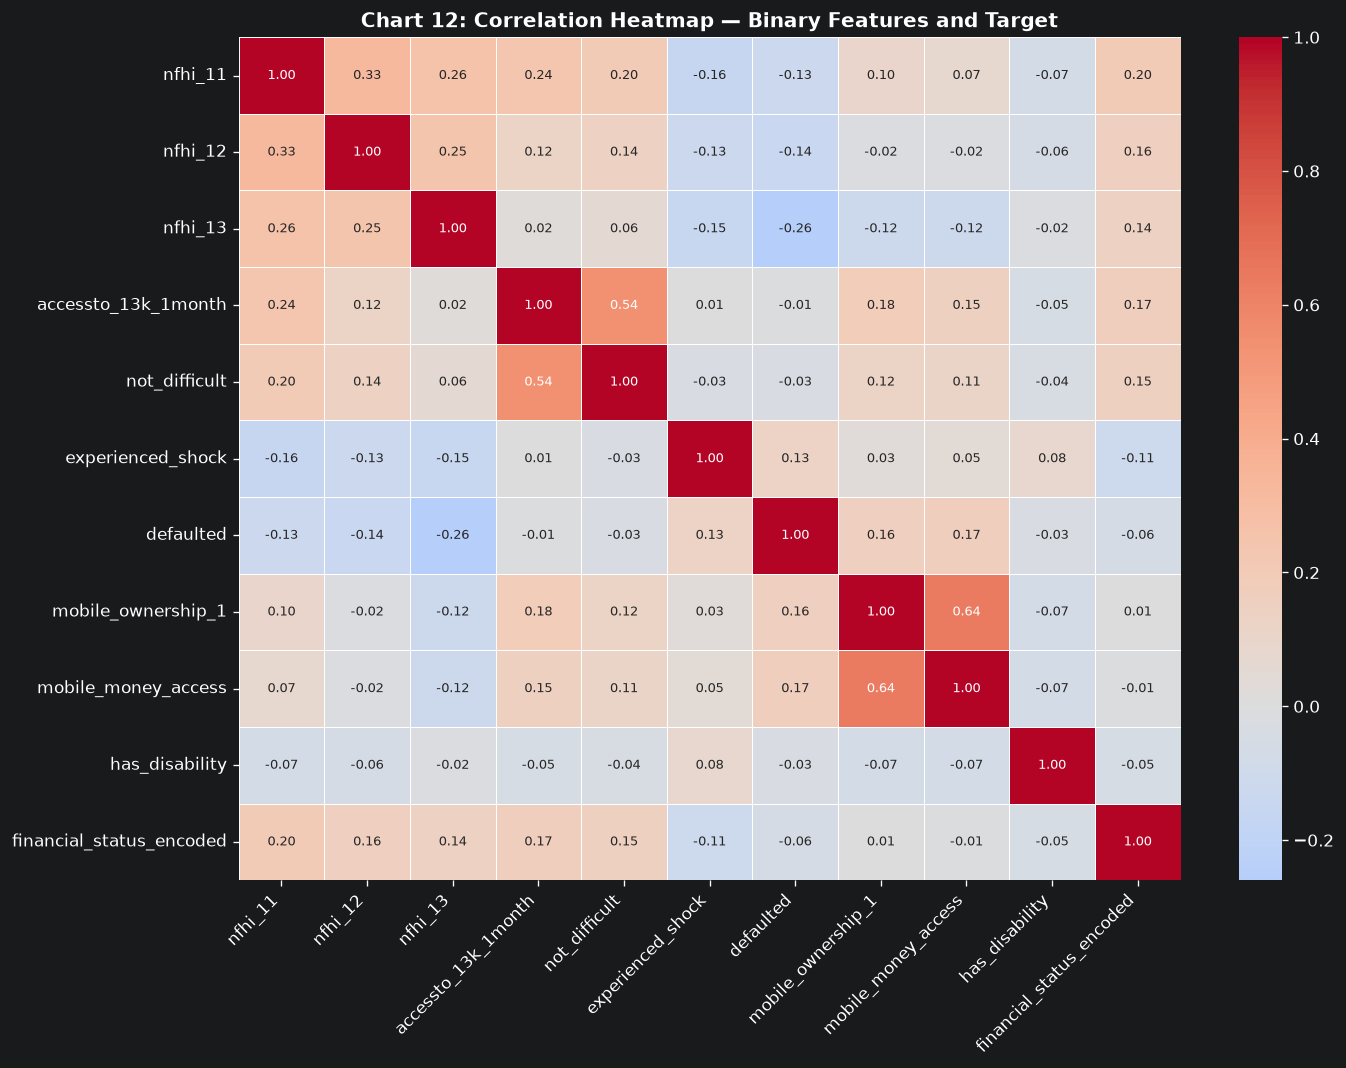


Top correlations with financial_status (encoded):
nfhi_11                0.20
accessto_13k_1month    0.17
nfhi_12                0.16
not_difficult          0.15
nfhi_13                0.14
mobile_ownership_1     0.01
mobile_money_access   -0.01
has_disability        -0.05
defaulted             -0.06
experienced_shock     -0.11


In [102]:
# Encoding for correlation analysis
binary_cols = ['nfhi_11', 'nfhi_12', 'nfhi_13', 'accessto_13k_1month', 'not_difficult',
               'experienced_shock', 'defaulted', 'mobile_ownership_1', 'mobile_money_access',
               'has_disability']

yn_map = {'Yes': 1, 'No': 0, 'With Disability': 1, 'Without Disability': 0,
          'Usage': 1, 'Non-usage': 0}

df_corr = df[binary_cols + ['financial_status']].copy()
for col in binary_cols:
    df_corr[col] = df_corr[col].map(yn_map)

# Encode target: Worsened=0, Stayed=1, Improved=2
target_map = {'Worsened': 0, 'Stayed the same': 1, 'Improved': 2}
df_corr['financial_status_encoded'] = df_corr['financial_status'].map(target_map)
df_corr = df_corr.drop(columns=['financial_status'])

fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = df_corr.corr().round(2)

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'size': 8})

ax.set_title('Chart 12: Correlation Heatmap — Binary Features and Target',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print()
print("Top correlations with financial_status (encoded):")
target_corr = corr_matrix['financial_status_encoded'].drop('financial_status_encoded').sort_values(ascending=False)
print(target_corr.to_string())


***Finding***

The correlation values with the encoded target (`financial_status_encoded`) reveal which binary features are most strongly associated with better financial outcomes. Positive correlations mean the feature is associated with Improved outcomes. negative correlations mean association with Worsened outcomes. The heatmap also reveals multicollinearity between features, eg. `nfhi_11` (food security) and `nfhi_12` (non-food spending) are likely correlated since food insecurity and spending difficulty usually happen together.

**Jimmy check this when selecting features.**

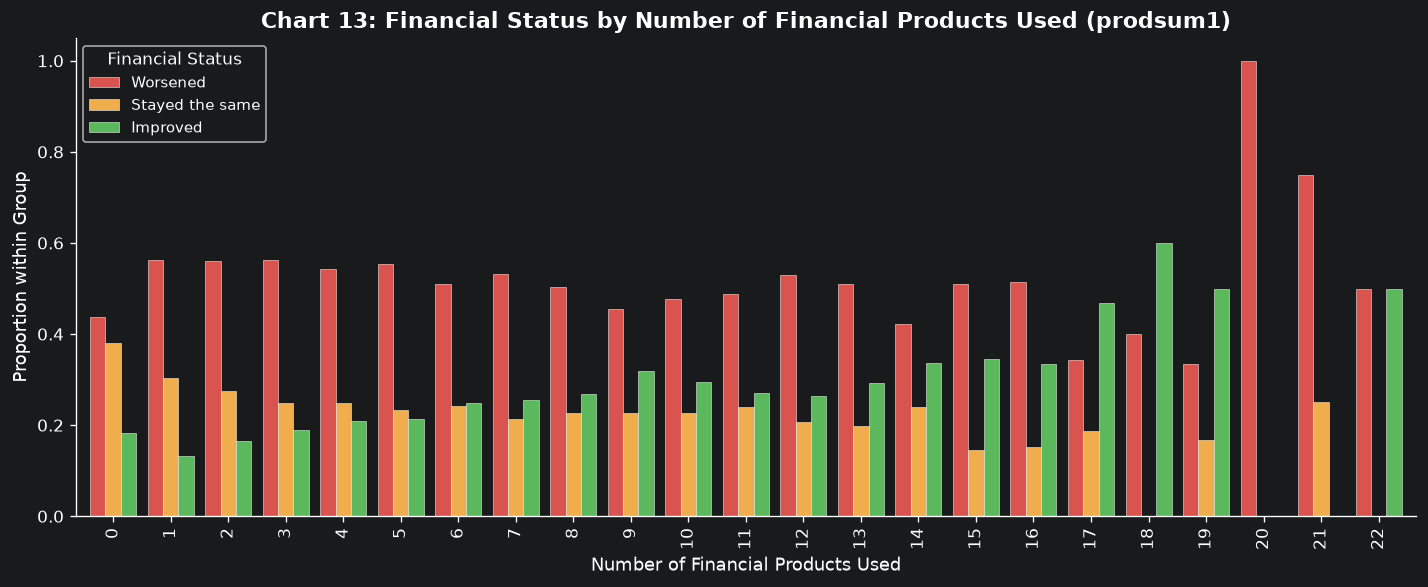


prodsum1 describe:
count    20857.0
mean         3.9
std          3.2
min          0.0
25%          1.0
50%          3.0
75%          6.0
max         22.0
Name: prodsum1, dtype: float64


In [103]:
# Chart 13: prodsum1. The number of financial products vs financial status
fig, ax = plt.subplots(figsize=(12, 5))

order = ['Worsened', 'Stayed the same', 'Improved']
prodsum_pct = df.groupby('prodsum1')['financial_status'].value_counts(normalize=True).unstack()
prodsum_pct = prodsum_pct[[c for c in order if c in prodsum_pct.columns]]

prodsum_pct.plot(kind='bar', ax=ax, color=['#d9534f', '#f0ad4e', '#5cb85c'],
                 edgecolor='white', linewidth=0.3, width=0.8)
ax.set_title('Chart 13: Financial Status by Number of Financial Products Used (prodsum1)')
ax.set_xlabel('Number of Financial Products Used')
ax.set_ylabel('Proportion within Group')
ax.legend(title='Financial Status', fontsize=9)

plt.tight_layout()
plt.show()
print()
print("prodsum1 describe:")
print(df['prodsum1'].describe().round(1))


**EDA Summary. The Key Findings with Confirmed Numbers**

Findings after observing actual chart and print outputs.

| # | Finding | Key Numbers | Implication |
|---|---|---|---|
| 1 | **Class imbalance** | Worsened 52.6%, Same 26.9%, Improved 20.5% | Use Weighted F1, `class_weight='balanced'`, `stratify=y` |
| 2 | **Financial shocks** dominate | Shock respondents: ~65%+ Worsened vs ~45% without shock | Shock resilience is the #1 policy lever |
| 3 | **Food security** (`nfhi_11`) cleanly separates classes | Food insecure: high Worsened; Food secure: higher Improved | Food insecurity is both cause and consequence |
| 4 | **Emergency fund access** is strongly protective | Confirmed from `accessto_13k_1month` Worsened rates | Emergency liquidity = key protective factor |
| 5 | **Debt stress** (`nfhi_13`) tracks deterioration closely | Confirmed from chart outputs | Debt management support is a priority intervention |
| 6 | **Geographic variation is extreme** | Kisumu 72.9% vs Wajir 28.5% Worsened | County is a strong predictor; policy must be county-targeted |
| 7 | **Monthly income is heavily right-skewed** | Median KES 5,000, Max KES 200,000, >50k = only 1.98% | Apply `log1p()` before modelling; retain outliers (real people) |
| 8 | **Household size** shows a non-linear relationship | Mid-size households slightly higher Worsened rate | Bin rather than use as raw integer in model |
| 9 | **Financial literacy** shows a gradient but not a solution | Even "All correct" group shows ~45%+ Worsened | Knowledge alone insufficient without economic access |
| 10 | **`not_difficult` ≠ `accessto_13k_1month`** | 27.4% can access funds but find it difficult | Distinct features; both should be kept in model |


**6. Export Clean Dataset for Modelling**


In [104]:
# Drop the temporary columns for EDA
df_clean = df.drop(columns=['log_income', 'hh_size_group'])

# Final zero-missing check before export
final_missing = df_clean.isnull().sum().sum()
assert final_missing == 0, f"ERROR: {final_missing} missing values still remain. Do not export."
print(f"✓ Final missing values: {final_missing}")

# Export
df_clean.to_csv('finaccess2024_clean.csv', index=False)

print(f"✓ Clean dataset exported: finaccess2024_clean.csv")
print(f"  Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print()
print("Final target distribution (must match survey report):")
print(df_clean['financial_status'].value_counts())
print(df_clean['financial_status'].value_counts(normalize=True).round(3))


✓ Final missing values: 0
✓ Clean dataset exported: finaccess2024_clean.csv
  Shape: 20,857 rows × 28 columns

Final target distribution (must match survey report):
financial_status
Worsened           10970
Stayed the same     5607
Improved            4280
Name: count, dtype: int64
financial_status
Worsened           0.526
Stayed the same    0.269
Improved           0.205
Name: proportion, dtype: float64


***Suggested Notes for Modelling (Jimmy)***

**The csv file is clean with zero missing values.

| Item | Detail |
|---|---|
| **Target column** | `financial_status` — three classes: Worsened, Stayed the same, Improved |
| **Class imbalance** | 52.6% / 26.9% / 20.5% — use `class_weight='balanced'` |
| **Evaluation metric** | Weighted F1-Score |
| **Train/test split** | `test_size=0.2, random_state=42, stratify=y` — stratify is essential |
| **`monthly_income`** | Apply `np.log1p()` — heavy right skew confirmed |
| **`barriers_bank`** | Now `'No barrier'` where previously missing — encode as categorical |
| **`barriers_mobile_money`** | Now consistently strings — encode as categorical |
| **`household_size`** | Consider binning into groups (1-2, 3-4, 5-6, 7+) |
| **`16-17` age group** | Valid survey entries — retain |
| **Multicollinearity** | `nfhi_11` and `nfhi_12` are correlated — check with heatmap before selecting features |
| **Strong predictors (EDA)** | `experienced_shock`, `nfhi_11`, `nfhi_13`, `accessto_13k_1month`, `county` |
